# Classification of Astronomical Events using CNNs (II)
```Authors: Paul Alvarez updated: 20260728```

This study implements and evaluates various computer vision models to classify astronomical events from the Zwicky Transient Facility (ZTF) survey. The main objective is to perform real-bogus classification using 63×63 pixel triplet images (science, reference, and difference) and analyze its performance in a reduced sample size. Additionally, it extends to multiclass classification (transient, periodic, stochastic) and includes transfer learning experiments using MobileNetV2 and Braai.


This second notebook covers the construction of the convolutional neural network baseline model. It also evaluates model enhancements through techniques such as data augmentation and transfer learning, while addressing the selection of an optimal decision threshold to control false positive and false negative rates in the real/bogus classification.

## Table of contents:
* [Required libraries](#Required-libraries)
* [Baseline model](#Baseline-model)
* [Optimization](#optimization)
* [References](#References)

## Required libraries

In [1]:
# visualizations and data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model performance metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

# Tensor (CNN's)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

# Helper functions
from functions import evaluate_cnn_model, plot_training_history

## Baseline model

Baseline model is defined: a 5-layer Convolutional Neural Network (3 convolutional layers and 2 dense/fully-connected layers) with a final sigmoid activation function for binary real/bogus classification

In [2]:
# Read the data of the previous notebook and split to train
X = np.load('../data/processed/X_data.npy')
y = np.load('../data/processed/y_labels.npy')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
# CNN baseline (based on TensorFlow documentation)
def baseline_cnn(input_shape=(63, 63, 3)):
    model = models.Sequential()

    # Convolutional layers
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))

    # Fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid')) # Output layer 

    # Compile
    model.compile(
        optimizer='adam',
        loss= 'binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
# Model training (only 8 epochs to prevent overfitting due to small dataset)
base_model = baseline_cnn(input_shape=(63,63,3))

history_base = base_model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

c:\Users\Paul\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.6685 - loss: 0.6091 - val_accuracy: 0.8077 - val_loss: 0.4692
Epoch 2/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8445 - loss: 0.3688 - val_accuracy: 0.8383 - val_loss: 0.3743
Epoch 3/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8770 - loss: 0.3062 - val_accuracy: 0.8474 - val_loss: 0.3762
Epoch 4/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8956 - loss: 0.2717 - val_accuracy: 0.8637 - val_loss: 0.3430
Epoch 5/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9086 - loss: 0.2398 - val_accuracy: 0.8728 - val_loss: 0.3131
Epoch 6/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9081 - loss: 0.2338 - val_accuracy: 0.8850 - val_loss: 0.3472
Epoch 7/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9254 - loss: 0.1986 - val_accuracy: 0.8881 - val_loss: 0.3152
Epoch 8/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9305 - loss: 0.1870 - val_accuracy: 

In [7]:
# Observe the architecture (this need discussion)
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 61, 61, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,938,821 (7.40 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,292,548 (4.93 MB)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8423 - loss: 0.4935
Accuracy: 0.8423194289207458
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


<Figure size 800x600 with 0 Axes>

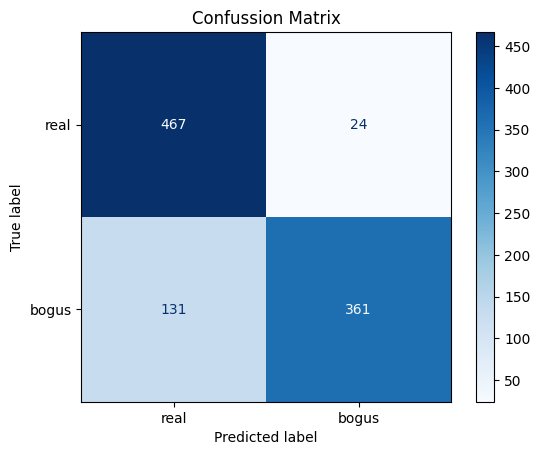


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.78      0.95      0.86       491
       bogus       0.94      0.73      0.82       492

    accuracy                           0.84       983
   macro avg       0.86      0.84      0.84       983
weighted avg       0.86      0.84      0.84       983



In [5]:
# Display the model performance metrics
loss_base, acc_base = base_model.evaluate(X_test, y_test)
print("Accuracy:", acc_base)
metrics_base = evaluate_cnn_model(base_model, X_test, y_test)

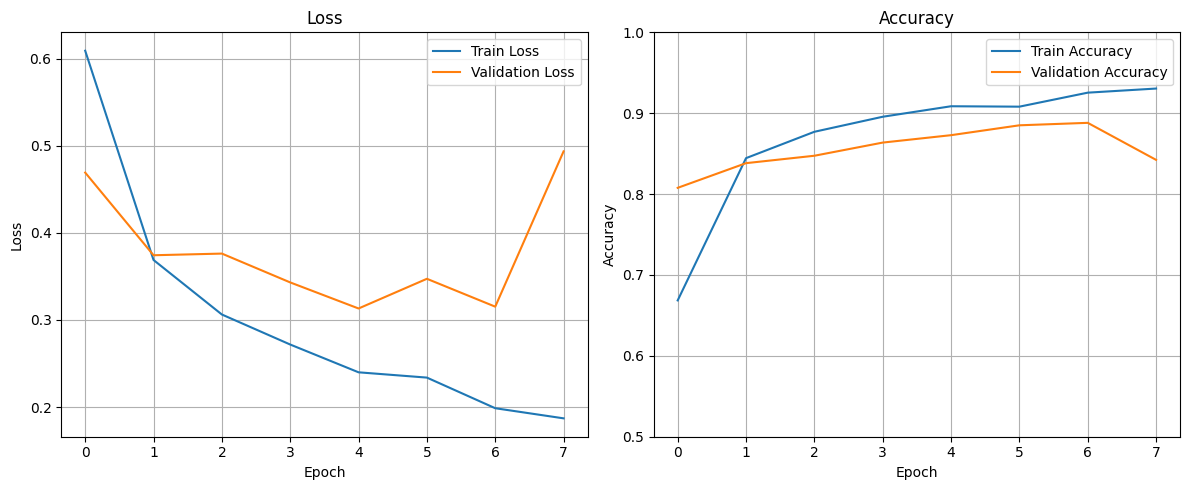

In [6]:
# Plot loss and accuracy visualization
plot_training_history(history_base)

The model achieves an overall accuracy of approximately 90%, demonstrating strong predictive capability well above random guessing. It exhibits high effectiveness to identify correct astronomical objects is high, as is its ability to identify both real and bogus objects. In the astronomy field, maximing the Recalll (or F1-score as well) for the real class is critical, as missinng true discoveries (false negatives such as ignoring a supernova explotion) carries a high science lost. In fact, the baseline model concentrating more false negative errors than false positives, therefore, this is a clear area for improvement.

Regarding the visualizations, the training loss decreases steadily throughout the epochs. However, the validation loss curve begins to diverge from epoch 2 onward, reaching its maximum gap at the final epoch, which provides clear evidence of overfitting. While the training and validation accuracy curves reamin close, a slight divergence emerges near the end, reinforcing the overfitting and epoch limit discussion.


Overall, we achieved competitive results for a lightweight baseline model on a limited dataset. Moving forward, Our goal going forward, beyond further improving predictive performance, our primary goal is to ensure consistencia across evaluation metrics which involvess enhancing model generaization, mitigating overfitting, and narrowing the gap between training and validation loss curves.

  


## Optimization

With the baseline model established, we now evaluate the impact of techniques such as data augmentation (artificially expanding  the dataset through flips, crops, and rotation of the images) and dropout (randomly deactivating neurons during training to prevent overfitting  and prioritize general feature representation) on stabilizing and improving our model:

In [9]:
# Baseline plus data augmentation and dropout
def baseline_cnn_plus(input_shape=(63, 63, 3), num_classes=10):
    model = models.Sequential()

    data_augmentation = tf.keras.Sequential([ #aug
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1, 0.1),
    ])


    # Convolutional layers
    model.add(data_augmentation) # plus data via augmentation

    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    #model.add(layers.BatchNormalization())  
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25)) # dropout

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    #model.add(layers.BatchNormalization())  
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25)) # dropout

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    #model.add(layers.BatchNormalization())  

    # Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    

    # This block is used for the multiclass extension in notebook III
    if num_classes <= 2:
        # Binary (Real vs Bogus) SIGMOIDE activation (used in this notebook)
        n_cat = 1
        activation = 'sigmoid'
        loss = 'binary_crossentropy'

    else:
        # Multiclass (3+) SOFTMAX activation
        n_cat = num_classes
        activation = 'softmax'
        loss = 'sparse_categorical_crossentropy' # simple label 0,1,2

    # Its depends on multiclass o binary classification
    model.add(layers.Dense(n_cat, activation=activation))

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )
    return model

Since regularization techniques such as data augmentation and dropout mitigate the risk of overfitting, the numbers of training epochs is setted higher to allow the network more time to achieve convergence and improve accuracy. Additionally, we implemented early stopping with a patience of 5 epochs to automatically halt training once the validation loss stabilizes, preventing extra computation. 

In [10]:
# training model
model_plus = baseline_cnn_plus(input_shape=(63,63,3), num_classes=2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_plus = model_plus.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32, # small dataset
    callbacks=[early_stop]
)

# architecture
model_plus.summary()

c:\Users\Paul\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.5751 - loss: 0.6452 - val_accuracy: 0.6539 - val_loss: 0.6115
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.7091 - loss: 0.5265 - val_accuracy: 0.7723 - val_loss: 0.5132
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7858 - loss: 0.4652 - val_accuracy: 0.7608 - val_loss: 0.4710
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.8205 - loss: 0.4471 - val_accuracy: 0.8308 - val_loss: 0.4386
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8339 - loss: 0.4139 - val_accuracy: 0.8104 - val_loss: 0.4152
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8456 - loss: 0.3616 - val_accuracy: 0.8486 - val_loss: 0.3761
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8549 - loss: 0.3539 - val_accuracy: 0.8651 - val_loss: 0.3294
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.8542 - loss: 0.3425 - val_accuracy: 0.8384 - 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 63, 63, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,938,821 (7.40 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,292,548 (4.93 MB)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9217 - loss: 0.2127
Accuracy: 0.9216683506965637
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


<Figure size 800x600 with 0 Axes>

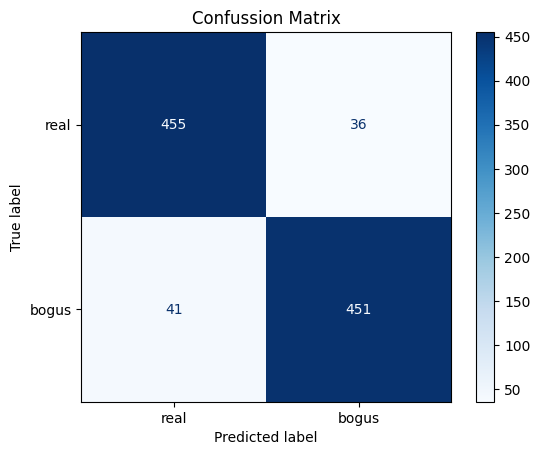


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.92      0.93      0.92       491
       bogus       0.93      0.92      0.92       492

    accuracy                           0.92       983
   macro avg       0.92      0.92      0.92       983
weighted avg       0.92      0.92      0.92       983



In [11]:
# Display the model performance metrics
loss_plus, acc_plus = model_plus.evaluate(X_test, y_test)
print("Accuracy:", acc_plus)
metrics_plus = evaluate_cnn_model(model_plus, X_test, y_test)

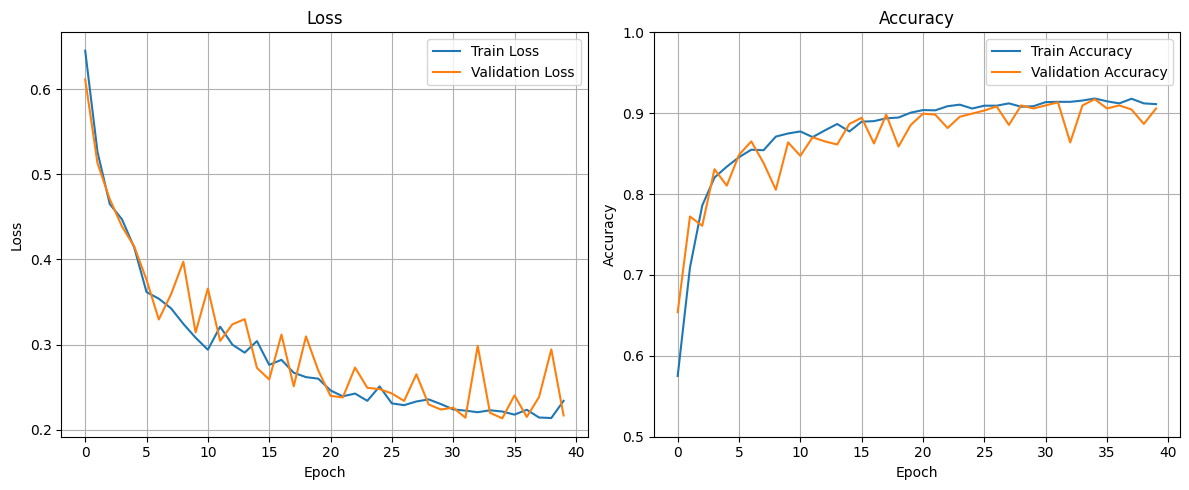

In [12]:
# Visualizations of the Loss and Accuracy
plot_training_history(history_plus)